# V31: LQ45 AI Strategy - Optimizing Threshold for TP/FP Ratio

This notebook focuses on maximizing the **Quality of Entry Signals** by optimizing the AI decision threshold based on the **TP/FP Ratio** (True Positives to False Positives).

### Objective:
- Find a threshold that results in the cleanest 'Bull' signals.
- High TP/FP ratio means most of the times the AI says 'Buy', the market actually goes up.
- This reduces 'Whipsaws' and unnecessary transaction costs.

### Logic:
1. **Iterative Search**: Scan thresholds from 0.40 to 0.70 on **Training Data**.
2. **Metric**: Calculate $Ratio = \frac{TP}{FP}$ for each step.
3. **Visualization**: Plot the curve to see the 'Sweet Spot'.
4. **Execution**: Apply this High-Confidence threshold to the 2025 LQ45 simulation.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data (LQ45 Dataset) ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1) 

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 712 rows


Training XGBoost and optimizing for Highest TP/FP Ratio...


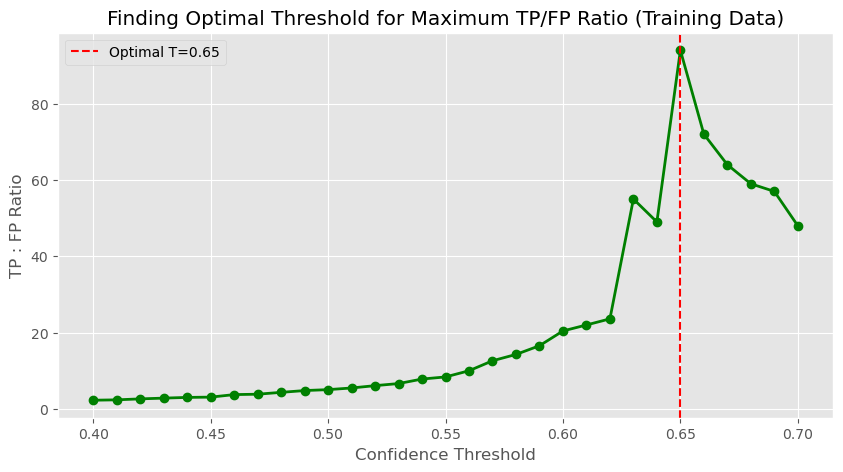

Targeting cleanest signals with Threshold: 0.65 (Ratio: 94.00)


In [2]:
# --- 2. Model Training & TP/FP Optimization ---

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
features = features.dropna()
target = (market_return.shift(-1) > 0).astype(int).reindex(features.index).fillna(0)

train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

print("Training XGBoost and optimizing for Highest TP/FP Ratio...")
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Search loop
train_probs = xgb_model.predict_proba(X_train)[:, 1]
thresholds = np.arange(0.40, 0.71, 0.01)
tp_fp_ratios = []

for t in thresholds:
    preds = (train_probs >= t).astype(int)
    if np.sum(preds) == 0:
        tp_fp_ratios.append(0)
        continue
    
    tn, fp, fn, tp = confusion_matrix(y_train, preds).ravel()
    # Ratio calculation (handling DivisionByZero)
    ratio = tp / fp if fp > 0 else tp
    tp_fp_ratios.append(ratio)

opt_idx = np.argmax(tp_fp_ratios)
opt_t = thresholds[opt_idx]

# Visualization of the Optimization Curve
plt.figure(figsize=(10, 5))
plt.plot(thresholds, tp_fp_ratios, color='green', marker='o', linewidth=2)
plt.axvline(opt_t, color='red', linestyle='--', label=f'Optimal T={opt_t:.2f}')
plt.title("Finding Optimal Threshold for Maximum TP/FP Ratio (Training Data)")
plt.xlabel("Confidence Threshold")
plt.ylabel("TP : FP Ratio")
plt.legend()
plt.grid(True)
plt.show()

print(f"Targeting cleanest signals with Threshold: {opt_t:.2f} (Ratio: {tp_fp_ratios[opt_idx]:.2f})")

In [3]:
# --- 3. Backtest Functions (Including Transaction Fees) ---

def get_mis_assets(returns_window, correlation_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    G.add_nodes_from(returns_window.columns)
    for i in range(len(returns_window.columns)):
        for j in range(i+1, len(returns_window.columns)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold:
                G.add_edge(returns_window.columns[i], returns_window.columns[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    def neg_sharpe(weights):
        p_ret = np.sum(weights * mu)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -p_ret / p_vol if p_vol > 0.0001 else 0
    res = minimize(neg_sharpe, [1./len(mu)]*len(mu), method='SLSQP', 
                   bounds=tuple((0, 1) for _ in range(len(mu))), 
                   constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation(test_dates, returns, ai_probs, threshold=0.5, fee=0.0025):
    val, history, dates = 100.0, [100.0], [test_dates[0]]
    prev_weights = {}
    
    for i, date in enumerate(test_dates[:-1]):
        # AI Gating
        is_risk_off = ai_probs.loc[date] < threshold
        
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-30:loc_idx]
        
        if is_risk_off:
            weights = {'CASH': 1.0}
        else:
            selected = get_mis_assets(window_rets)
            weights = optimize_markowitz(window_rets[selected])
        
        # Fee Calculation
        all_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets)
        val -= (val * turnover * fee)
        
        # Execute
        next_date = test_dates[i+1]
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[next_date, a] for a, w in weights.items())
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        prev_weights = weights
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

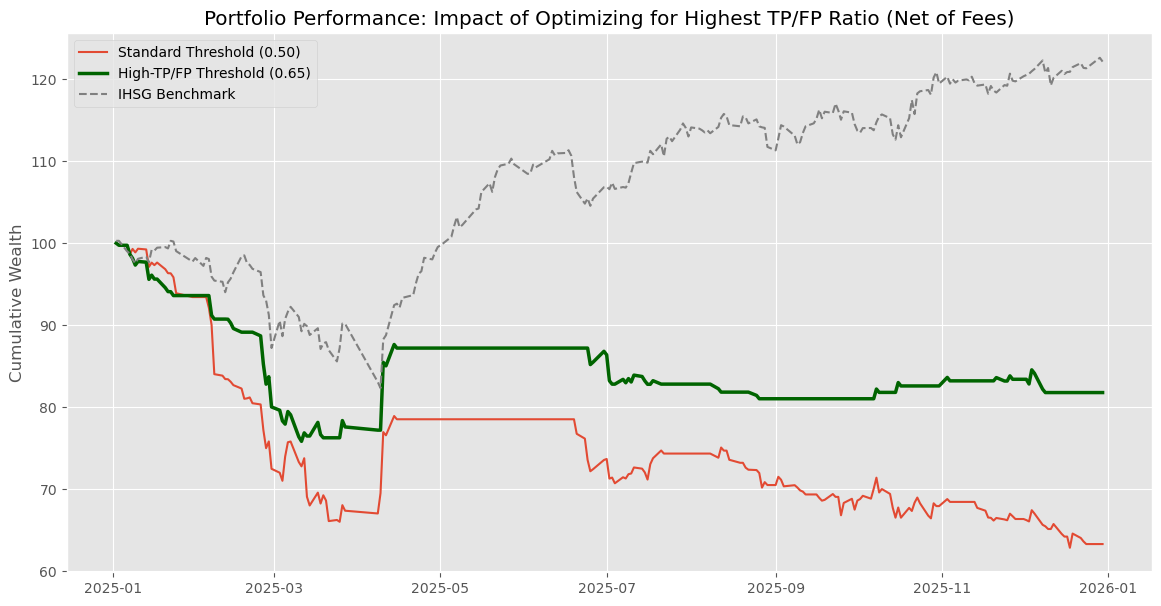

Standard (0.50) -> Return: -36.67%, MaxDD: -37.12%
Optimized (0.65) -> Return: -18.20%, MaxDD: -24.15%


In [4]:
# --- 4. Backtest Execution (2025 Out-of-Sample) ---
test_dates = X_test.index
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=test_dates)
fee = 0.0025

res_std = run_simulation(test_dates, returns, test_probs, threshold=0.5, fee=fee)
res_opt = run_simulation(test_dates, returns, test_probs, threshold=opt_t, fee=fee)
benchmark = pd.DataFrame({'Portfolio_Value': (market_return.loc[test_dates].cumsum().apply(np.exp) * 100)}, index=test_dates)

plt.figure(figsize=(14, 7))
plt.plot(res_std.index, res_std['Portfolio_Value'], label="Standard Threshold (0.50)")
plt.plot(res_opt.index, res_opt['Portfolio_Value'], label=f"High-TP/FP Threshold ({opt_t:.2f})", linewidth=2.5, color='darkgreen')
plt.plot(benchmark.index, benchmark['Portfolio_Value'], label="IHSG Benchmark", linestyle='--', color='gray')
plt.title("Portfolio Performance: Impact of Optimizing for Highest TP/FP Ratio (Net of Fees)")
plt.ylabel("Cumulative Wealth")
plt.legend()
plt.grid(True)
plt.show()

# Metrics
def get_metrics(df):
    ret = (df['Portfolio_Value'].iloc[-1] / 100) - 1
    mdd = (df['Portfolio_Value'] / df['Portfolio_Value'].cummax() - 1).min()
    return f"{ret:.2%}", f"{mdd:.2%}"

print(f"Standard (0.50) -> Return: {get_metrics(res_std)[0]}, MaxDD: {get_metrics(res_std)[1]}")
print(f"Optimized ({opt_t:.2f}) -> Return: {get_metrics(res_opt)[0]}, MaxDD: {get_metrics(res_opt)[1]}")